In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [15]:
transactions = pd.read_csv("transaction_data.csv")
products = pd.read_csv("product.csv")
campaigns = pd.read_csv("campaign_table.csv")
campaign_desc = pd.read_csv("campaign_desc.csv")
coupon = pd.read_csv("coupon.csv")
coupon_redempt = pd.read_csv("coupon_redempt.csv")
hh_demographics = pd.read_csv("hh_demographic.csv")
causal_data = pd.read_csv("causal_data.csv")


In [16]:
daily_metrics = transactions.groupby('DAY').agg(
    num_transactions=('BASKET_ID', 'nunique'),
    total_sales=('SALES_VALUE', 'sum'),
    total_quantity=('QUANTITY', 'sum'),
    total_coupon_discount=('COUPON_DISC', 'sum'),
    distinct_stores=('STORE_ID', 'nunique'),
    distinct_households=('household_key', 'nunique')
).reset_index()

daily_metrics['avg_transaction_value'] = (daily_metrics['total_sales'] / daily_metrics['num_transactions']).round(2)
daily_metrics['avg_basket_size'] = (daily_metrics['total_quantity'] / daily_metrics['num_transactions']).round(2)

daily_metrics = daily_metrics.sort_values('DAY')


In [17]:
daily_metrics

,DAY,num_transactions,total_sales,total_quantity,total_coupon_discount,distinct_stores,distinct_households,avg_transaction_value,avg_basket_size
0,1,16,549.31,302,-9.29,15,15,34.33,18.88
1,2,13,458.91,156,-3.55,10,12,35.30,12.00
2,3,44,1560.37,678,-2.80,30,33,35.46,15.41
3,4,44,1785.64,849,-1.10,30,36,40.58,19.30
4,5,25,856.93,368,0.00,21,23,34.28,14.72
...,...,...,...,...,...,...,...,...,...
706,707,363,10632.36,409667,-37.48,106,310,29.29,1128.56
707,708,384,9949.90,445522,-75.34,104,315,25.91,1160.21
708,709,379,11245.74,355172,-67.78,108,317,29.67,937.13
709,710,406,12758.04,424690,-86.23,104,339,31.42,1046.03


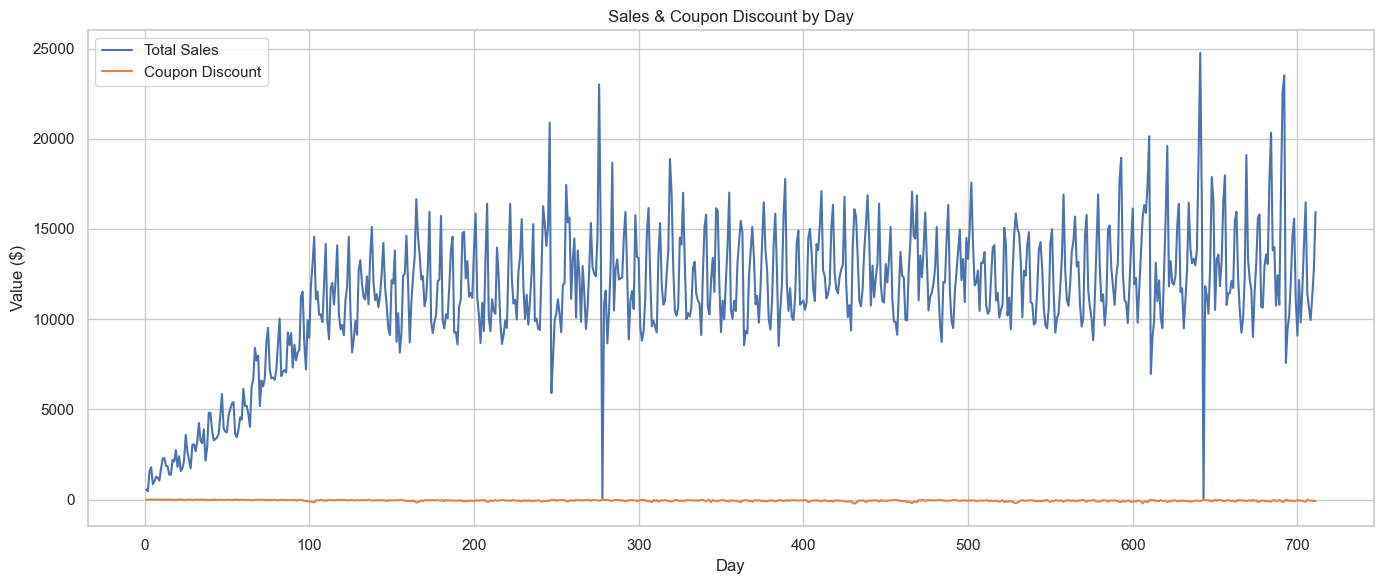

In [18]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="total_sales", label="Total Sales")
sns.lineplot(data=daily_metrics, x="DAY", y="total_coupon_discount", label="Coupon Discount")
plt.title("Sales & Coupon Discount by Day")
plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.legend()
plt.tight_layout()
plt.show()

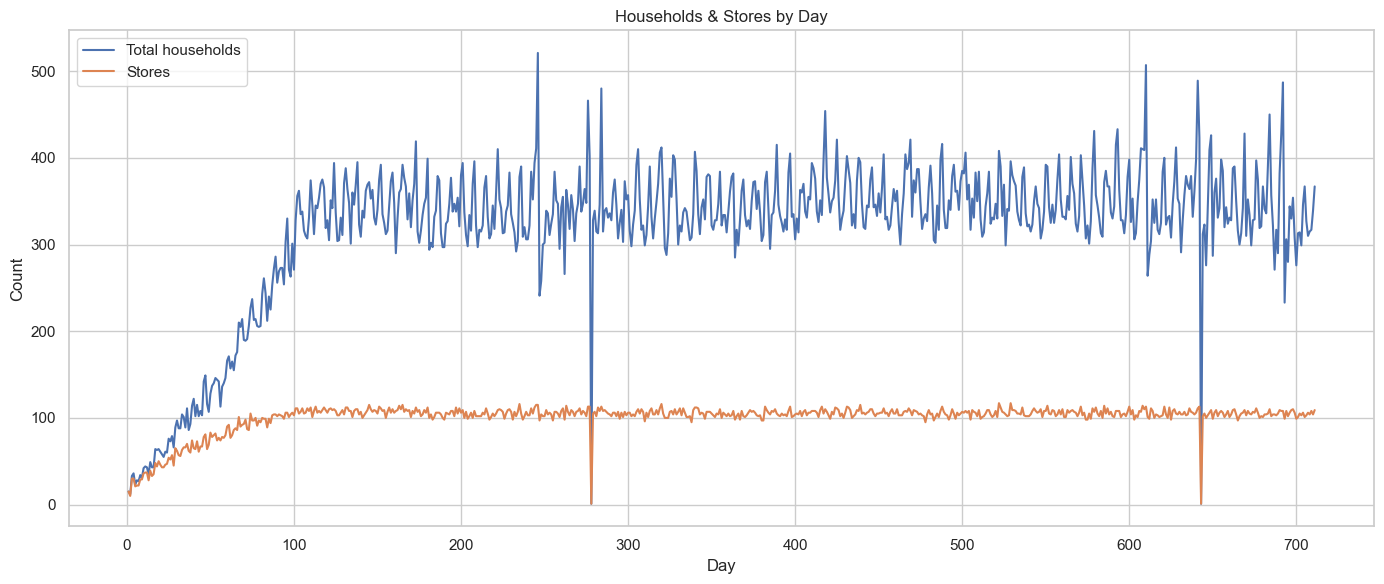

In [19]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_households", label="Total households")
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_stores", label="Stores")
plt.title("Households & Stores by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

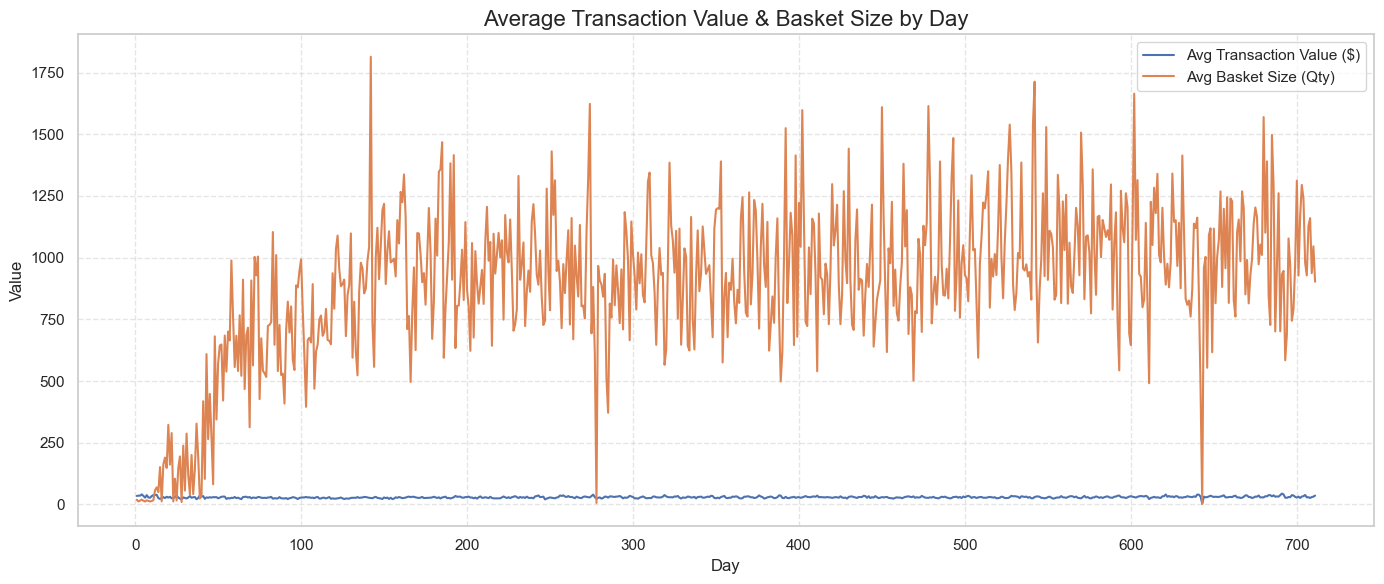

In [20]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_metrics, x="DAY", y="avg_transaction_value", label="Avg Transaction Value ($)")
sns.lineplot(data=daily_metrics, x="DAY", y="avg_basket_size", label="Avg Basket Size (Qty)")

plt.title("Average Transaction Value & Basket Size by Day", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
transaction_aggregate = pd.DataFrame({
    'households': [transactions['household_key'].nunique()],
    'baskets': [transactions['BASKET_ID'].nunique()],
    'days': [transactions['DAY'].nunique()]
})
print(transaction_aggregate)


   households  baskets  days
0        2500   276484   711


In [22]:
transaction_aggregate2 = hh_demographics[['household_key']].drop_duplicates().sort_values('household_key').reset_index(drop=True)


In [23]:
transaction_aggregate2

,household_key
0,1
1,7
2,8
3,13
4,16
...,...
796,2494
797,2496
798,2497
799,2498


0    372393.76
1     87945.30
2    124700.87
3     36003.30
4     31162.40
Name: LoyaltyScore, dtype: float64


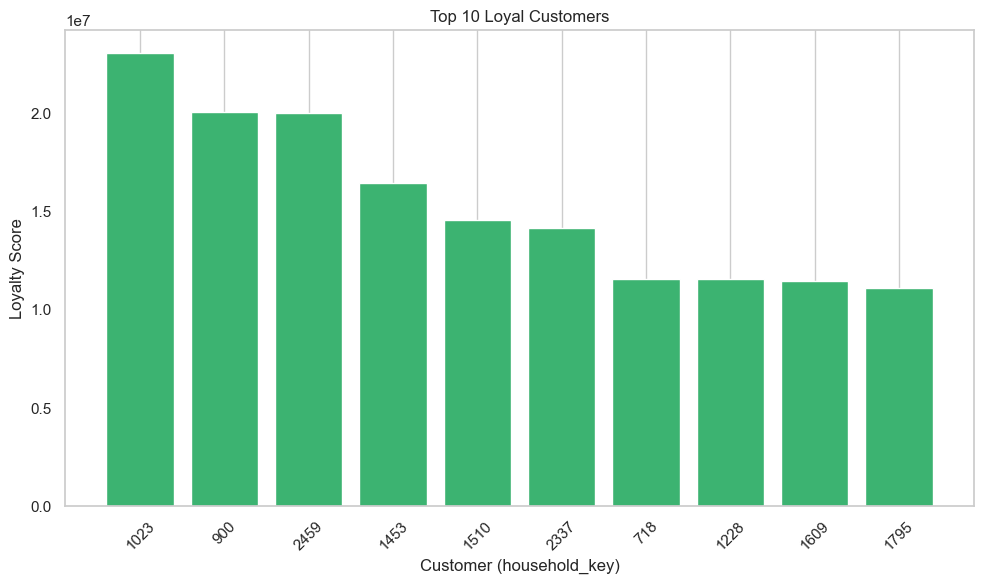

In [24]:
basket_summary = transactions.groupby(['household_key', 'BASKET_ID']).agg({
    'SALES_VALUE': 'sum',
    'DAY': 'min',
    'WEEK_NO': 'min'
}).reset_index()

customer_summary = basket_summary.groupby('household_key').agg({
    'BASKET_ID': 'nunique',
    'SALES_VALUE': 'sum',
    'WEEK_NO': ['min', 'max', 'nunique']
}).reset_index()

customer_summary.columns = ['household_key', 'TotalBaskets', 'TotalSpent', 'FirstWeek', 'LastWeek', 'ActiveWeeks']
#loyality score = customer total spent * totalbaskets
customer_summary['LoyaltyScore'] = customer_summary['TotalSpent'] * customer_summary['TotalBaskets']

top_customers = customer_summary.sort_values('LoyaltyScore', ascending=False).head(10)

print(customer_summary['LoyaltyScore'].head())
plt.figure(figsize=(10, 6))
plt.bar(top_customers['household_key'].astype(str), top_customers['LoyaltyScore'], color='mediumseagreen')
plt.xlabel('Customer (household_key)')
plt.ylabel('Loyalty Score')
plt.title('Top 10 Loyal Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()



Customer Loyalty Summary:
   household_key  TotalBaskets  TotalSpent  FirstWeek  LastWeek  ActiveWeeks  \
0              1            86     4330.16          8       102           68   
1              2            45     1954.34         15        96           35   
2              3            47     2653.21         17       101           37   
3              4            30     1200.11         16        90           26   
4              5            40      779.06         13       101           27   

   LoyaltyScore  
0     372393.76  
1      87945.30  
2     124700.87  
3      36003.30  
4      31162.40  


C:\Users\gratu\AppData\Local\Temp\ipykernel_222464\167999303.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers['household_key'].astype(str), y=top_customers['LoyaltyScore'], palette="viridis")


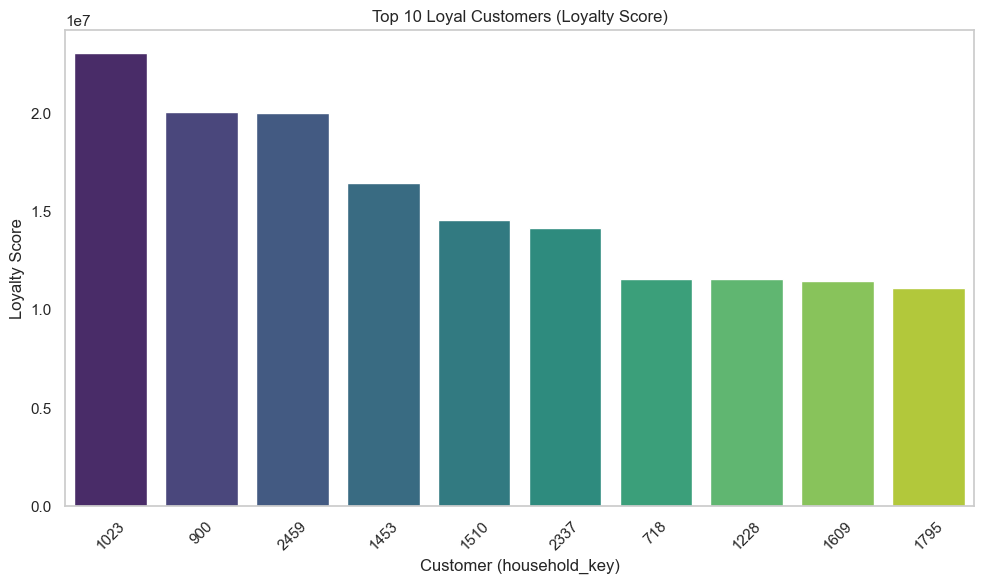

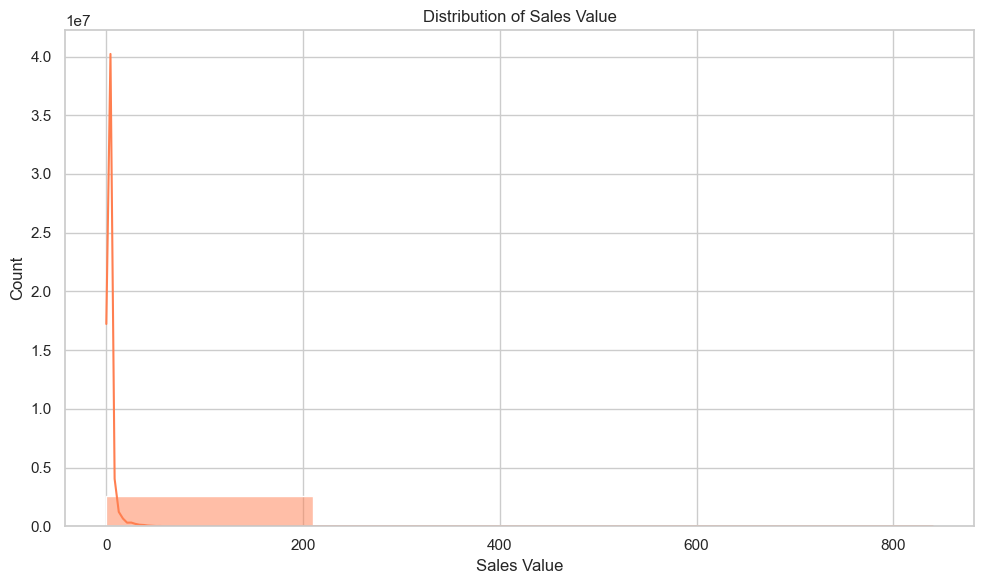

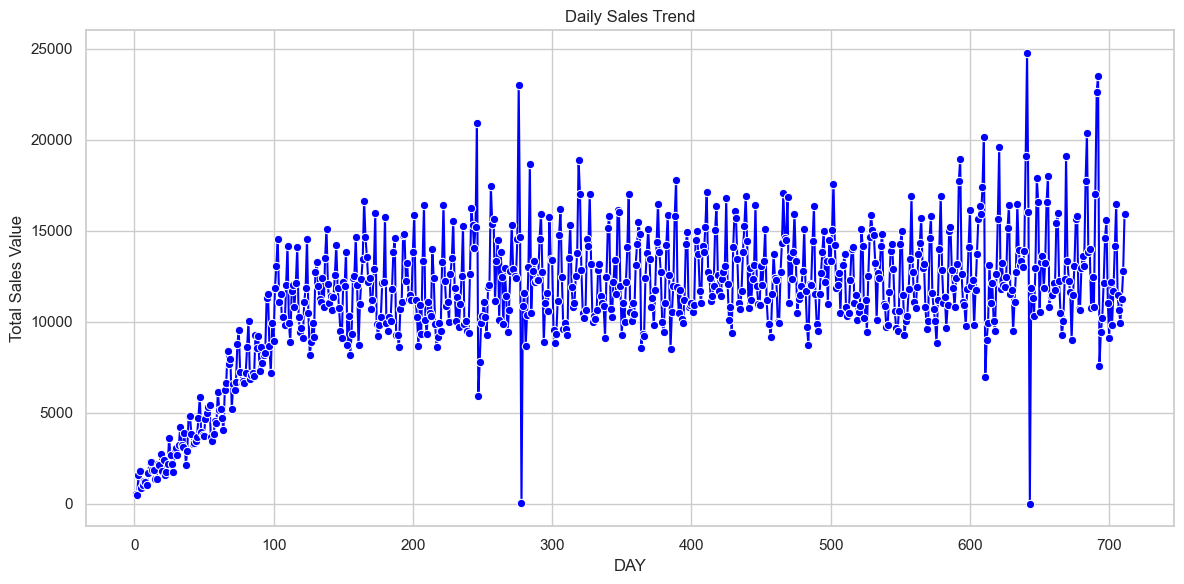

C:\Users\gratu\AppData\Local\Temp\ipykernel_222464\167999303.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products['PRODUCT_ID'].astype(str), y=top_products['QUANTITY'], palette="magma")


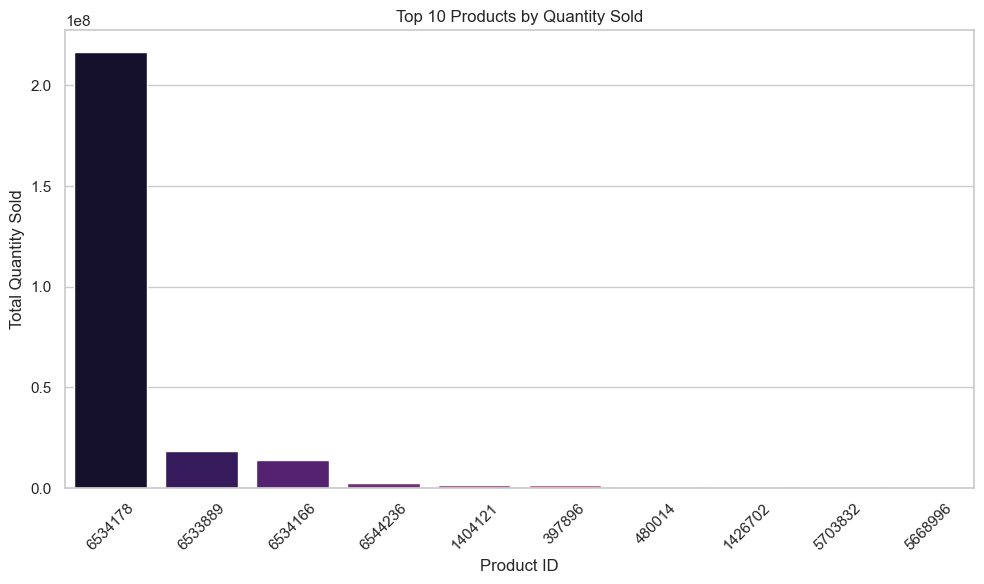

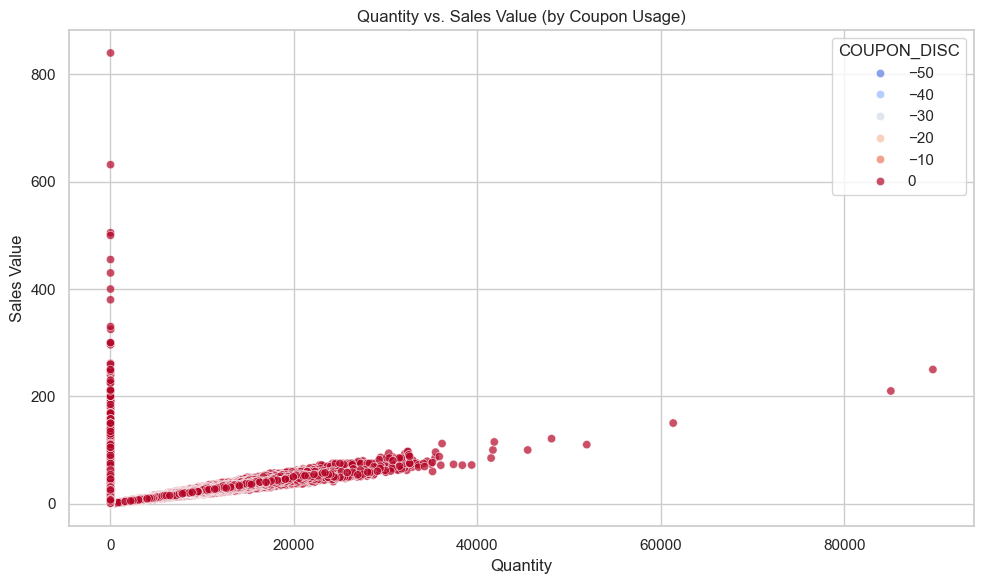

C:\Users\gratu\AppData\Local\Temp\ipykernel_222464\167999303.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TimeOfDay', data=transactions, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='Set2')


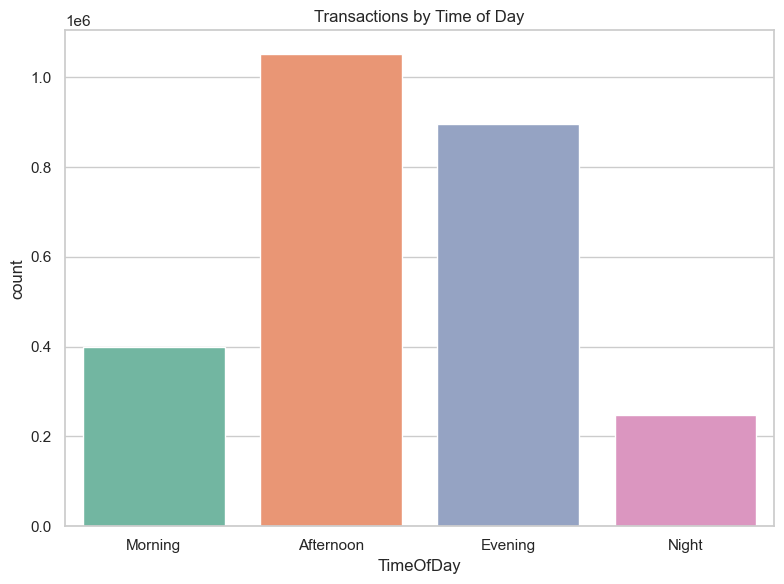

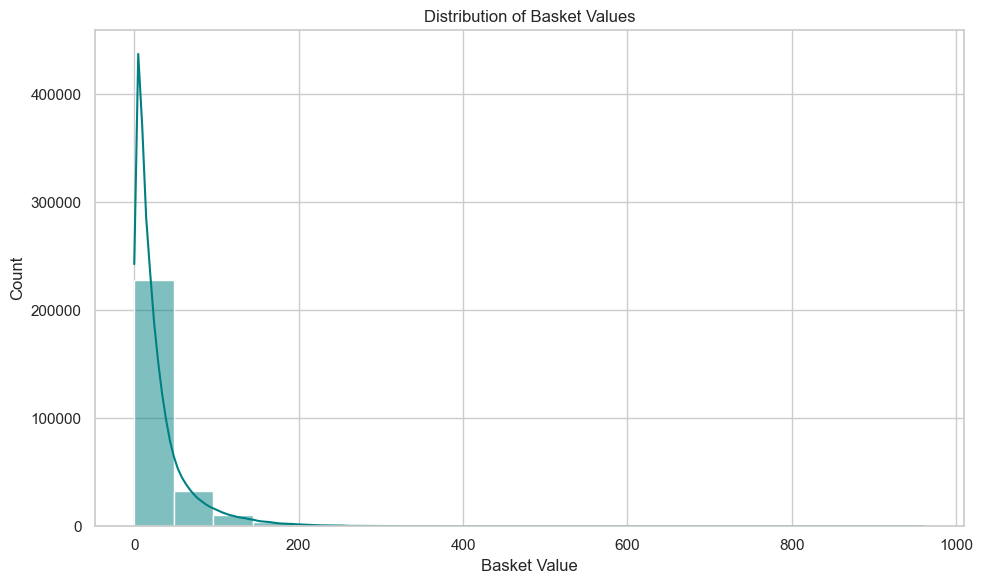

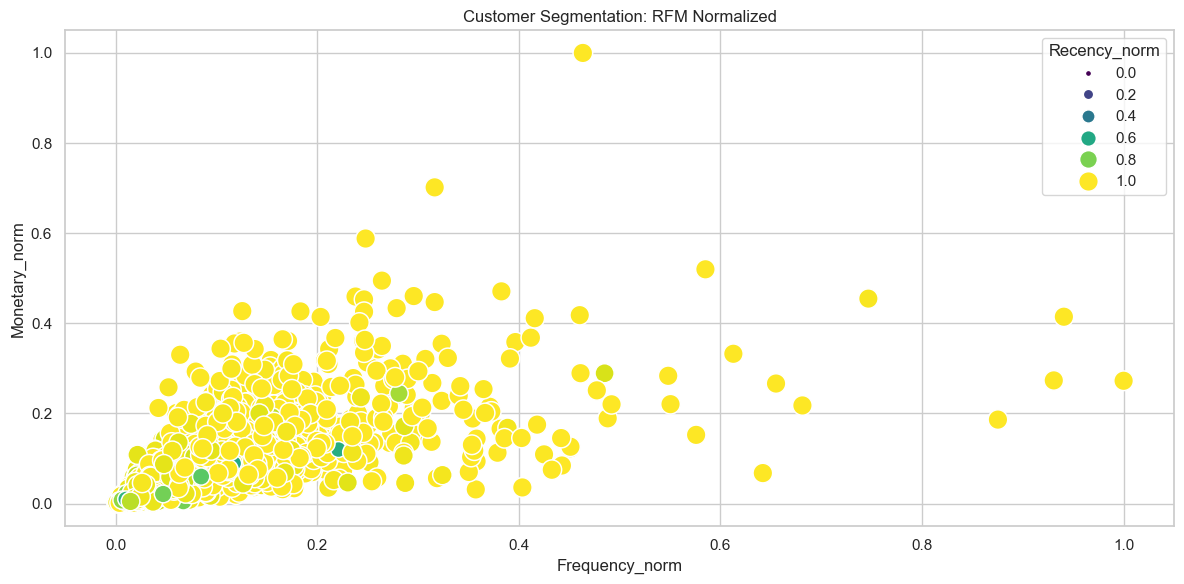

C:\Users\gratu\AppData\Local\Temp\ipykernel_222464\167999303.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_stats, x='PRODUCT_ID', y='IsDiscounted', palette='coolwarm')


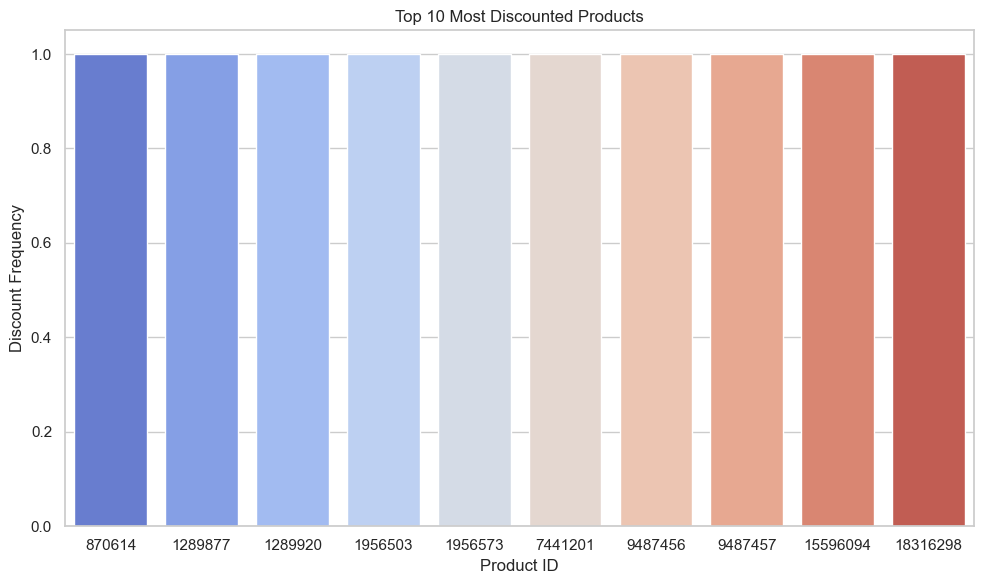

In [25]:
customer_summary['LoyaltyScore'] = customer_summary['TotalSpent'] * customer_summary['TotalBaskets']
print("\nCustomer Loyalty Summary:")
print(customer_summary.head())



#top loyal customers
top_customers = customer_summary.sort_values('LoyaltyScore', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers['household_key'].astype(str), y=top_customers['LoyaltyScore'], palette="viridis")
plt.xlabel('Customer (household_key)')
plt.ylabel('Loyalty Score')
plt.title('Top 10 Loyal Customers (Loyalty Score)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# Transaction Value Distribution
plt.figure(figsize=(10, 6))
sns.histplot(transactions['SALES_VALUE'], kde=True, color='coral', bins=4)
plt.xlabel('Sales Value')
plt.title('Distribution of Sales Value')
plt.tight_layout()
plt.show()



# Assume a random date with the start date as 2024 01 01

daily_sales = transactions.groupby('DAY')['SALES_VALUE'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='DAY', y='SALES_VALUE', data=daily_sales, marker='o', color='blue')
plt.xlabel('DAY')
plt.ylabel('Total Sales Value')
plt.title('Daily Sales Trend')
plt.tight_layout()
plt.show()


#  Top products 
top_products = transactions.groupby('PRODUCT_ID')['QUANTITY'].sum().reset_index().sort_values('QUANTITY', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products['PRODUCT_ID'].astype(str), y=top_products['QUANTITY'], palette="magma")
plt.xlabel('Product ID')
plt.ylabel('Total Quantity Sold')
plt.title('Top 10 Products by Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quantity vs. Sales Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='QUANTITY', y='SALES_VALUE', data=transactions, hue='COUPON_DISC', alpha=0.7, palette='coolwarm')
plt.xlabel('Quantity')
plt.ylabel('Sales Value')
plt.title('Quantity vs. Sales Value (by Coupon Usage)')
plt.tight_layout()
plt.show()

def get_time_of_day(time_val):
    hour = int(str(time_val).zfill(4)[:2])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

transactions['TimeOfDay'] = transactions['TRANS_TIME'].apply(get_time_of_day)

plt.figure(figsize=(8, 6))
sns.countplot(x='TimeOfDay', data=transactions, order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='Set2')
plt.title('Transactions by Time of Day')
plt.tight_layout()
plt.show()

# Basket-level Stats
basket_summary = transactions.groupby('BASKET_ID').agg(
    BasketSize=('QUANTITY', 'sum'),
    BasketValue=('SALES_VALUE', 'sum'),
    NumProducts=('PRODUCT_ID', 'nunique'),
).reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(basket_summary['BasketValue'], kde=True, bins=20, color='teal')
plt.xlabel('Basket Value')
plt.title('Distribution of Basket Values')
plt.tight_layout()
plt.show()

# net sepnd = SALES_VALUE + all discounts
transactions['NetSpend'] = transactions['SALES_VALUE'] + transactions['RETAIL_DISC'] + transactions['COUPON_DISC'] + transactions['COUPON_MATCH_DISC']

# RFM
customer_rfm = transactions.groupby('household_key').agg(
    Recency=('DAY', 'max'),
    Frequency=('BASKET_ID', pd.Series.nunique),
    Monetary=('NetSpend', 'sum')
).reset_index()

# normalize for plotting
customer_rfm[['Recency_norm', 'Frequency_norm', 'Monetary_norm']] = customer_rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

plt.figure(figsize=(12, 6))
sns.scatterplot(data=customer_rfm, x='Frequency_norm', y='Monetary_norm', size='Recency_norm', hue='Recency_norm', palette='viridis', sizes=(20, 200))
plt.title('Customer Segmentation: RFM Normalized')
plt.tight_layout()
plt.show()

# Discount analysis
transactions['IsDiscounted'] = (transactions[['RETAIL_DISC', 'COUPON_DISC', 'COUPON_MATCH_DISC']].sum(axis=1) < 0).astype(int)
discount_stats = transactions.groupby('PRODUCT_ID')['IsDiscounted'].mean().reset_index().sort_values(by='IsDiscounted', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=discount_stats, x='PRODUCT_ID', y='IsDiscounted', palette='coolwarm')
plt.title('Top 10 Most Discounted Products')
plt.xlabel('Product ID')
plt.ylabel('Discount Frequency')
plt.tight_layout()
plt.show()


